<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/Project_Machine_Learning_Personal_Loan_Campaign(Logistic_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Context**


AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

## **Objective**
To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and to identify which segment of customers to target more.

**Data Dictionary**
* **ID:** Customer ID
* **Age:** Customer’s age in completed years
* **Experience:** # years of professional experience
* **Income:** Annual income of the customer (in thousand dollars)
* **ZIP Code**: Home Address ZIP code.
* **Family:** The family size of the customer
* **CCAvg:** Average spending on credit cards per month (in thousand dollars)
* **Education:** Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* **Mortgage:** Value of house mortgage if any. (in thousand dollars)
* **Personal_Loan:** Did this customer accept the personal loan offered in the last campaign?
* **Securities_Account:** Does the customer have a securities account with the bank?
* **CD_Account:** Does the customer have a certificate of deposit (CD) account with the bank?
* **Online:** Do customers use Internet banking facilities?
* **CreditCard:** Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?

In [1]:
# importining neccessary libraries to load/read/visualize the data
import pandas as pd
import numpy as np
import math

#importing visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# to maintain number precision
pd.options.display.float_format = '{:.3f}'.format

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# to split data into training & testing
from sklearn.model_selection import train_test_split

# to scale data
from sklearn.preprocessing import StandardScaler

# to build logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
# connecting drive to load data from drive into this working invornment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Load data
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/Loan_Modelling.csv')
  print(" 🚀 Data loaded successfuly")
except Exception as a :
  print(a)

 🚀 Data loaded successfuly


In [4]:
# making data copy to keep maintain original data
df = data.copy()

In [5]:
# table checking
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.600,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.500,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.000,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.700,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.000,2,0,0,0,0,0,1


In [6]:
# table shape
rows, columns = df.shape
print(f"Total Rows : {rows} \nTotal Columns : {columns}")

Total Rows : 5000 
Total Columns : 14


In [7]:
# table info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


* Total 14 column in table, all are numerical column.
* Total 5000 rows are there in table
* There no null value present in data


In [8]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


* There is no null value is there in table

In [9]:
df.duplicated().sum()

np.int64(0)

* There is a no duplicates in table

In [10]:
# checking table stats
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.000,2500.500,1443.520,1.000,1250.750,2500.500,3750.250,5000.000
Age,5000.000,45.338,11.463,23.000,35.000,45.000,55.000,67.000
Experience,5000.000,20.105,11.468,-3.000,10.000,20.000,30.000,43.000
Income,5000.000,73.774,46.034,8.000,39.000,64.000,98.000,224.000
ZIPCode,5000.000,93169.257,1759.455,90005.000,91911.000,93437.000,94608.000,96651.000
Family,5000.000,2.396,1.148,1.000,1.000,2.000,3.000,4.000
CCAvg,5000.000,1.938,1.748,0.000,0.700,1.500,2.500,10.000
Education,5000.000,1.881,0.840,1.000,1.000,2.000,3.000,3.000
Mortgage,5000.000,56.499,101.714,0.000,0.000,0.000,101.000,635.000
Personal_Loan,5000.000,0.096,0.295,0.000,0.000,0.000,0.000,1.000


* Total 5000 recordes in table.

* ID Column is unique identifier for each row, it not usefull for further analysis. So we will drop this column.

* customer **age ranges between 27-67 year** old. average age is around 45 years. CV is around 0.25 indicating **High variation** in Customer Age.

* **Work experience ranges from 0 to 43 years**. However, **some values are less than 0, which likely indicates input errors** these will be treated as null values.
The coefficient of variation (CV) is 0.57, indicating a **high level of variability** in customer experience.

* On an average **annual income around 73.77 dollars.** CV is 0.62 indicating very high variance in annual income. **(data is highly dispersed around the mean)**

* Zipcode column is representing the location code it should be in category column, so we will convert this column into category data type.

* The Family column represents the number of members in a customer's household, ranging from 1 to 4. **On average, there are 2 members** per household.

* **On an average customer has 1.94 thousund dollars spending via credit card monthly.** Cv is 0.90 which is **indicating very high variance in credit card spend monthly ( data is very highly dispersed around the mean ).**

* The customer base is composed of individuals with varying educational backgrounds, where up to **25% are undergraduates, up to 50% are graduates, and the remaining customers are highly qualified professionals.**

* **Around 75% of customers already have mortgages (Home Loan)**, indicating a **highly credit-active customer base.** This presents strong opportunities for cross-selling additional loan products rather than focusing solely on new loan acquisition.
     * **Most customers are already engaged with loan products (good sign)**
     * **Customers are comfortable taking loans**

* **From the previous loan campaign, only 10% of customers showed interest in the personal loan offer**, indicating relatively **low customer inclination toward personal loans.**

* From this total customer base only 10% customers has their Security Account
in bank. **bold text**

* Only **6% customers has their Deposite certificate** from bank.

* **60% customers using online banking services.** indecating good signs for online banking serveses.

* **29%** of customers are using **Credit cards.**

In [11]:
# in table ID column is there, it not required to further analysis,
# ID column is a unique identifier for the each row so we plan to drop the column from the table.
df.drop('ID', axis = 1, inplace = True)

In [12]:
df['ZIPCode'] = df['ZIPCode'].astype(str)

* Droped ID column & changed the data type of ZIPCode column

As we mentioned above, we replacing the experience column of those values whoes experience is negative value with group by methode by Age Column.

Because **'Age' attribute strongly related to the Experience column.**

In [13]:
# change the value of experiences whoes < 0 with null
df['Experience'].mask(df['Experience'] < 0, np.nan, inplace=True)

In [14]:
# Filling the null values in experience columns
df['Experience'] = df['Experience'].fillna(df.groupby(['Age'])['Experience'].transform('mean'))

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          4988 non-null   float64
 2   Income              5000 non-null   int64  
 3   ZIPCode             5000 non-null   object 
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal_Loan       5000 non-null   int64  
 9   Securities_Account  5000 non-null   int64  
 10  CD_Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 507.9+ KB


In [16]:
# After filling null values with mean value.
df[df['Experience'].isnull()]

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
670,23,NaN,61,92374,4,2.600,1,239,0,0,0,1,0
909,23,NaN,149,91709,1,6.330,1,305,0,0,0,0,1
2430,23,NaN,73,92120,4,2.600,1,0,0,0,0,1,0
2618,23,NaN,55,92704,3,2.400,2,145,0,0,0,1,0
2717,23,NaN,45,95422,4,0.600,2,0,0,0,0,1,1
2962,23,NaN,81,91711,2,1.800,2,0,0,0,0,0,0
3130,23,NaN,82,92152,2,1.800,2,0,0,1,0,0,1
3157,23,NaN,13,94720,4,1.000,1,84,0,0,0,1,0
3425,23,NaN,12,91605,4,1.000,1,90,0,0,0,1,0
3824,23,NaN,12,95064,4,1.000,1,0,0,1,0,0,1


**Note : After this methode, 12 cases are still remaining as null so, now we decisided to replace this values by median value of experience column, because our data size is not large that much, so droping is not good practice ( dropping is totally depend on business requirement) so we filling this values with median value.**

In [17]:
df['Experience'] = df['Experience'].fillna(df['Experience'].median())

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   float64
 2   Income              5000 non-null   int64  
 3   ZIPCode             5000 non-null   object 
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal_Loan       5000 non-null   int64  
 9   Securities_Account  5000 non-null   int64  
 10  CD_Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 507.9+ KB


* All null values are filled. No null values are present

In [19]:
df.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1.000,49,91107,4,1.600,1,0,0,1,0,0,0
1,45,19.000,34,90089,3,1.500,1,0,0,1,0,0,0
2,39,15.000,11,94720,1,1.000,1,0,0,0,0,0,0
3,35,9.000,100,94112,1,2.700,2,0,0,0,0,0,0
4,35,8.000,45,91330,4,1.000,2,0,0,0,0,0,1


## **EDA ( Exploratory Data Analysis )**

In [20]:
# Univariate analysis

def histplot_boxplot(df, features:list):

  """
  Plot Histogram and Boxplot for given features.

    Parameters:
    df : pandas.DataFrame
        Input dataset
    features : list
        List of numerical column names

    Returns:
    None
  """

  n_column = 3
  n_rows = math.ceil(len(features)/n_column)
  # Defining the plot size of histogram
  plt.figure(figsize = (18, 3*n_rows))
  # plotting the histplot using features & data
  for j, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, j + 1)
    sns.histplot(data = df, x = feature, kde = True, color = 'skyblue')

    plt.title(f"Histogram of {feature}")
  plt.tight_layout
  plt.show()

    # ploting boxplot using features list & data
  plt.figure(figsize = (18, 3* n_rows))
  for k, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, k + 1)
    sns.boxplot(data = df, x = feature, color = 'lightgreen')

    plt.title(f"Boxplot of {feature}")

  plt.tight_layout
  plt.show()

In [21]:
def count_plot(data, x):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Summary table
    summary = (
        data.groupby(x)
        .size()
        .div(len(data))
        .reset_index(name='Percentage')
    )

    # Figure size based on categories
    n = data[x].nunique()
    plt.figure(figsize=(n * 3, 4))

    # Plot
    plot = sns.countplot(data=data, x=x, palette="viridis")

    # Add labels on bars
    for container in plot.containers:
        plot.bar_label(container)

    plt.title(f"{x} Distribution")
    plt.xlabel(x)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

    return summary

In [22]:
# bi-variate Analysis

def bargraph_plot(data, x, hue):

  summary = data.groupby([x, hue]).size().div(data.shape[0]).reset_index(name = 'Percentage')

  n = data[x].nunique()  # total unique values
  plt.figure(figsize = (n*3.5, 4))   # figure size
  bar_width = min(0.8, max(0.8, 2/n))  # set bar width
  plt.title(f"{x} Vs. {hue}") # title
  plot = sns.countplot(data=data, x = x, hue = hue, palette= "viridis" , width = bar_width)  # plotting graph
  # plt.ylim(0,  data[hue].value_counts().max()) # set bar hight
  for value in plot.containers :   # plotting values on bar
    plot.bar_label(value)
  return summary
  plt.show()

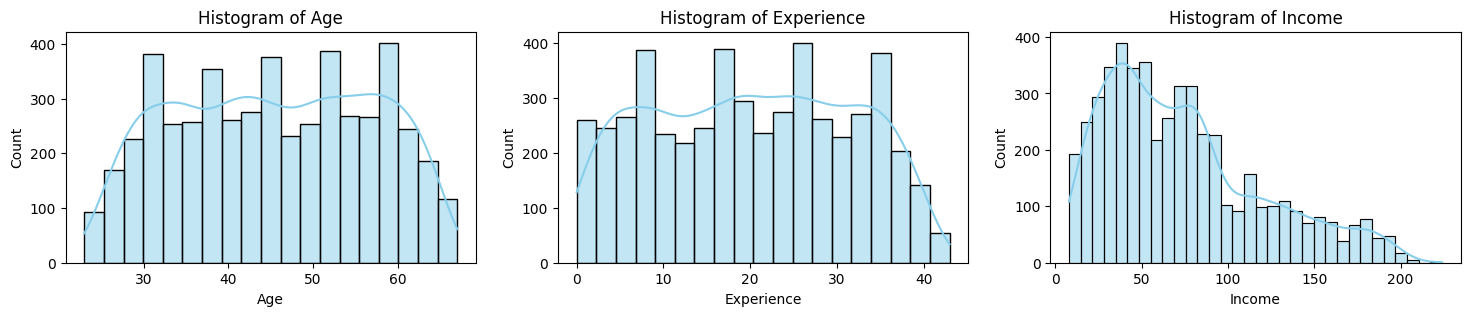

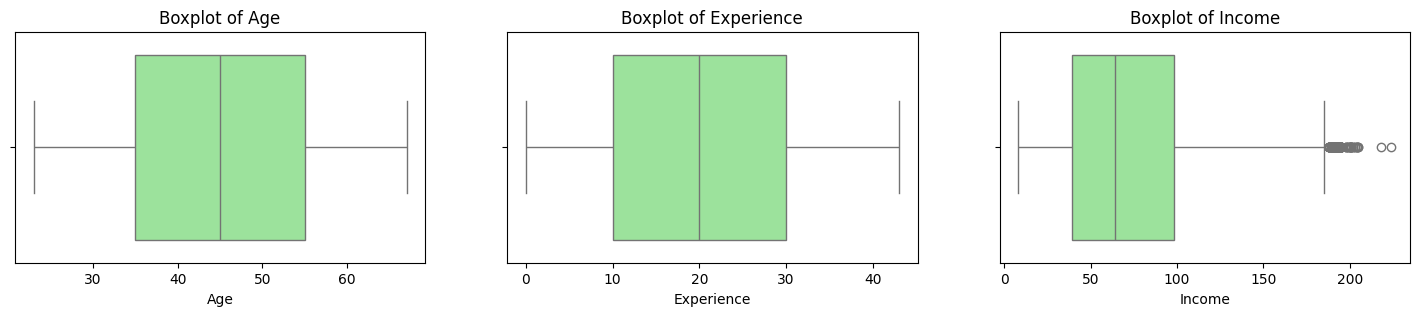

In [23]:
features = ['Age', 'Experience', 'Income']
histplot_boxplot(df, features)

## **Age :**

   * Customers age ranges approximetly from 25 to 65 years, indecating diverse cuatomer base.
   * Fairly Uniform distribution. histogram is evenly spread. No strong skweness.
   * Box plot showing median around 45-50 years.
   * outliers are not present. Age data is clean & consistent

## **Experience :**
   * Customer Professional Experiences is ranges from 0 to 45 years. Indicating customers some customers are 0 yr's experience but they might be borrower or depositer & some customers are high professional experience.
   * Experience is fairly uniform distrubted. On an average customers has 20 years experience as a professional.
   * Outliers are not present.

## **Income :**
   * The histogram shows a right-skewed distribution, indicating that most customers fall in the lower to mid-income range, while a smaller number of customers have very high incomes.
   * Approximately 50% of customers have an annual income of up to around 65,000 dollars(median level).
   * A portion of customers earn higher incomes, reaching up to around 190,000 dollars.
A few customers have incomes beyond this range, which are considered outliers as seen in the boxplot.

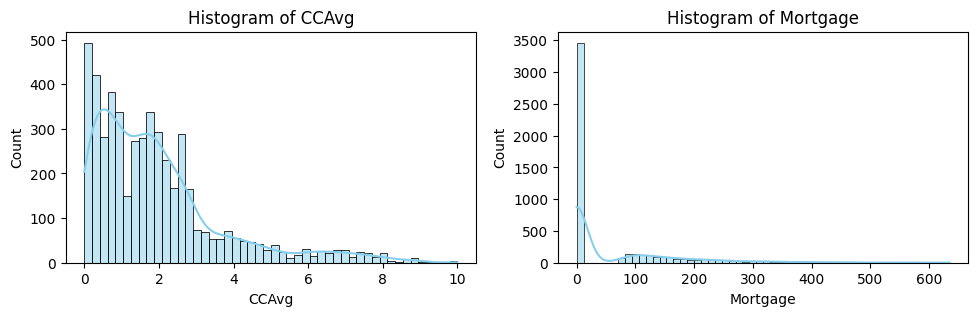

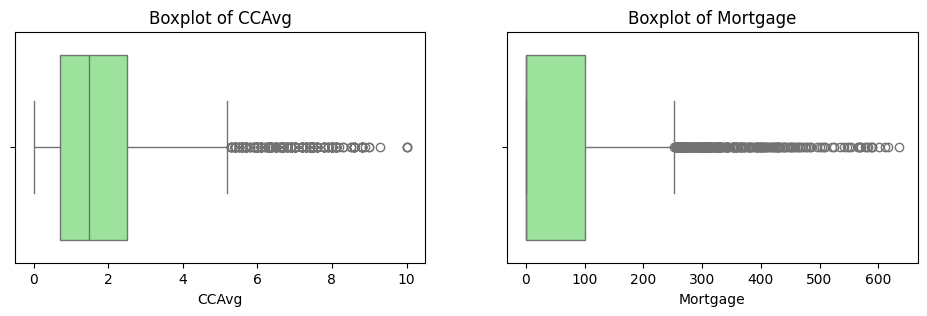

In [24]:
features = ['CCAvg',	'Mortgage']
histplot_boxplot(df, features)

## **CCAvg :**

  * Right-Skewed distribution, Majority of customers have low credit card average spending.
  * Most of the customers are in 0.4 to 2.5 range.
  * Box plot showa many points beyond upper upper whisker
  * High variability among top spenders.
  * Outliers are very high.

## **Mortgage :**
  * Highly right skewed Distribution.
  * Many customers don’t have mortgage loans
  * Boxplot shows many outliers beyond ~300 up to 600+
  * outliers are very high.
  * Data is not uniformly distributed

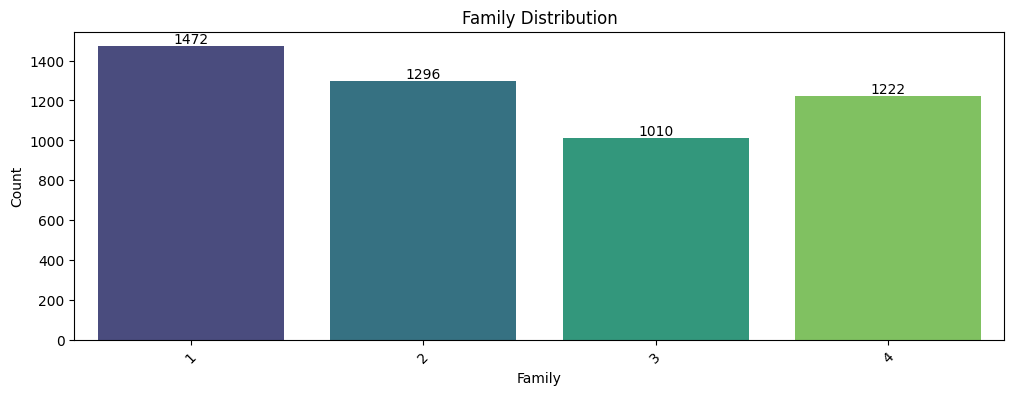

,Family,Percentage
0,1,0.294
1,2,0.259
2,3,0.202
3,4,0.244


In [25]:
count_plot(df, 'Family')

* 29% of the customers have 1 member in there family. 26% customers have 2 members in there family.
* Might be 29% customers whoes have one member in there family those are interseted or not for personal loan. or else might be 24% of customers whoes family size is 4/3 those are interested or not for personal loan.

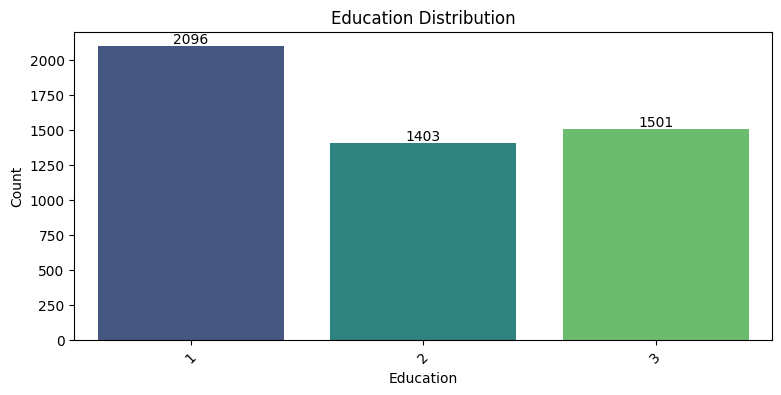

,Education,Percentage
0,1,0.419
1,2,0.281
2,3,0.300


In [26]:
count_plot(df, 'Education')

* 42% customers are professional/ high educational background.

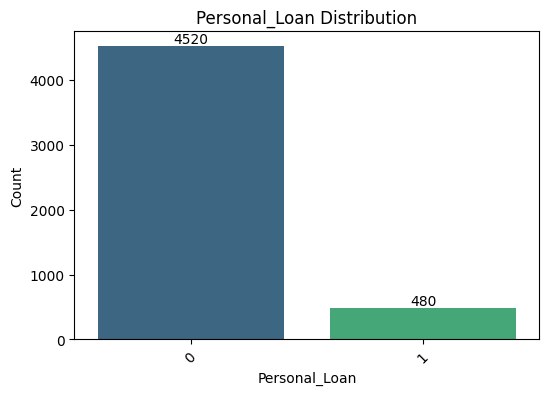

,Personal_Loan,Percentage
0,0,0.904
1,1,0.096


In [27]:
count_plot(df, 'Personal_Loan')

* Only 10% customers was shown interest on Personal loan. (in previous campaign)

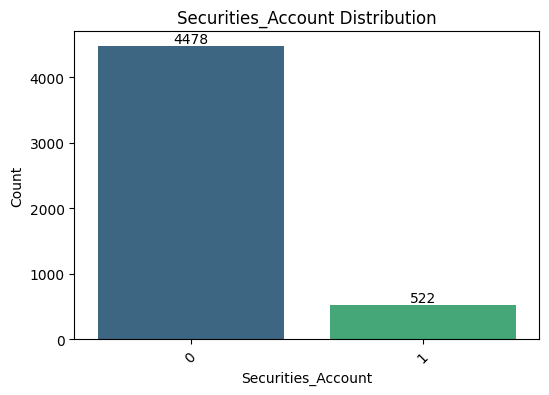

,Securities_Account,Percentage
0,0,0.896
1,1,0.104


In [28]:
count_plot(df, 'Securities_Account')

* Only 10% customers are have there securitie account in bank.

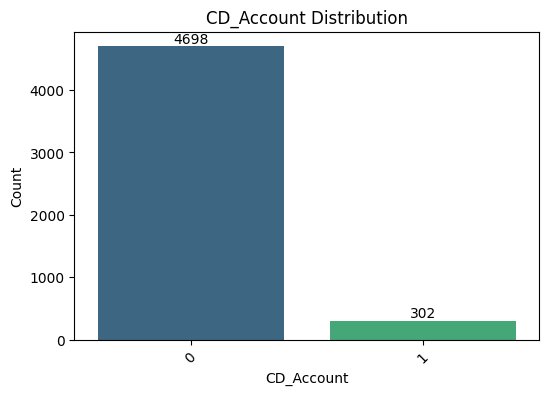

,CD_Account,Percentage
0,0,0.940
1,1,0.060


In [29]:
count_plot(df, 'CD_Account')

* Only 6% of customers whoes have there deposite certificate from bank.

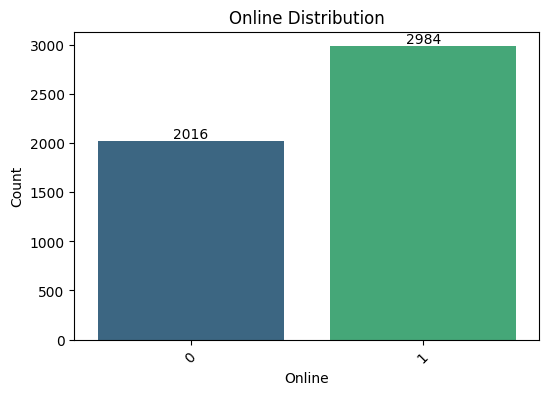

,Online,Percentage
0,0,0.403
1,1,0.597


In [30]:
count_plot(df, 'Online')

* 60% customers were taking all facilities experience from online services of bank.

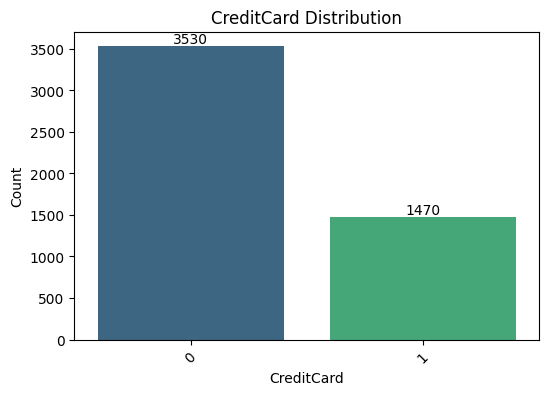

,CreditCard,Percentage
0,0,0.706
1,1,0.294


In [31]:
count_plot(df, 'CreditCard')

* Approximately 29% of customers hold credit cards from other banks, indicating a potential opportunity for them to consider taking a loan from AllLife bank.

### **Output (Dependent Variable):**

- In this case, AllLife Bank aims to expand its loan business within its existing customer base. Therefore, the **Personal_Loan** column is considered as the target (dependent) variable.

- The objective is to predict whether a customer will accept a personal loan by identifying key influencing factors. This will help the bank target the right customers, optimize marketing campaigns, and ultimately increase loan business growth.

**Note :** We are going to bi-variate analysis on the basis of Personal loan column with other attributes.

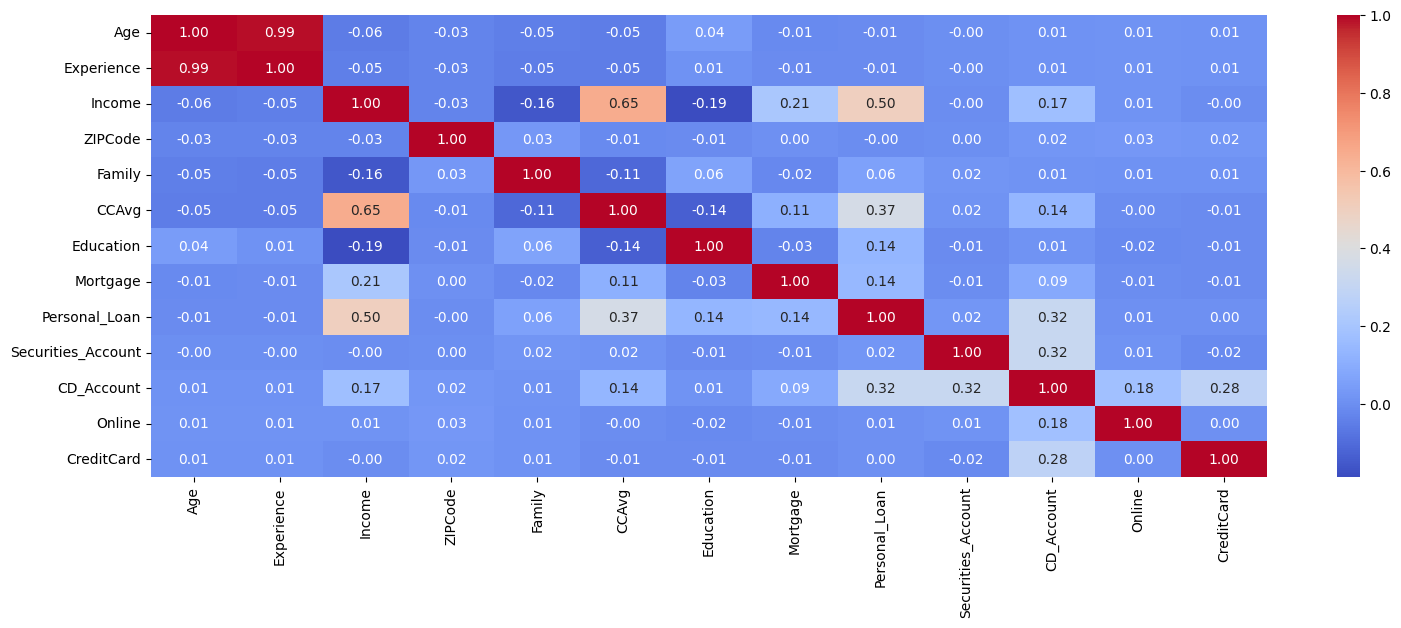

In [32]:
# checking the correlation between the all variables

# set figure size
plt.figure(figsize = (18, 6))
# plotting heatmap for correlation
sns.heatmap(data = df.select_dtypes(include = ['number', 'category', 'object']).corr(), annot = True, fmt = '0.2f', cmap = 'coolwarm' )
plt.show()

* Personal Loan & Income having strong positive correlation around 0.50. Income increses it will influence the loan amount. more income more loan amount might be.

* Age & Experience having negative correlation with personal loan. correlation around -0.01

* A correlation of +0.32 between Certificate of Deposit (CD account) and Personal Loan indicates a moderate positive relationship. Customers who have a CD account are somewhat more likely to take a personal loan. But the relationship is not strong, so it’s not the only deciding factor.

* Average spending on credit cards per Month and personal loan have a correlation of +0.37 indicates a moderate positive relationship.

* Education & Mortgage having +0.14 correlation between them. Indicating week positive correlation.

* A correlation of +0.06 between security account, family with personal loan have weak positive correlation.

* The customer whose taking all services from online those customers & loan amount attributes having weak positive correlation between them.

<Figure size 1400x800 with 0 Axes>

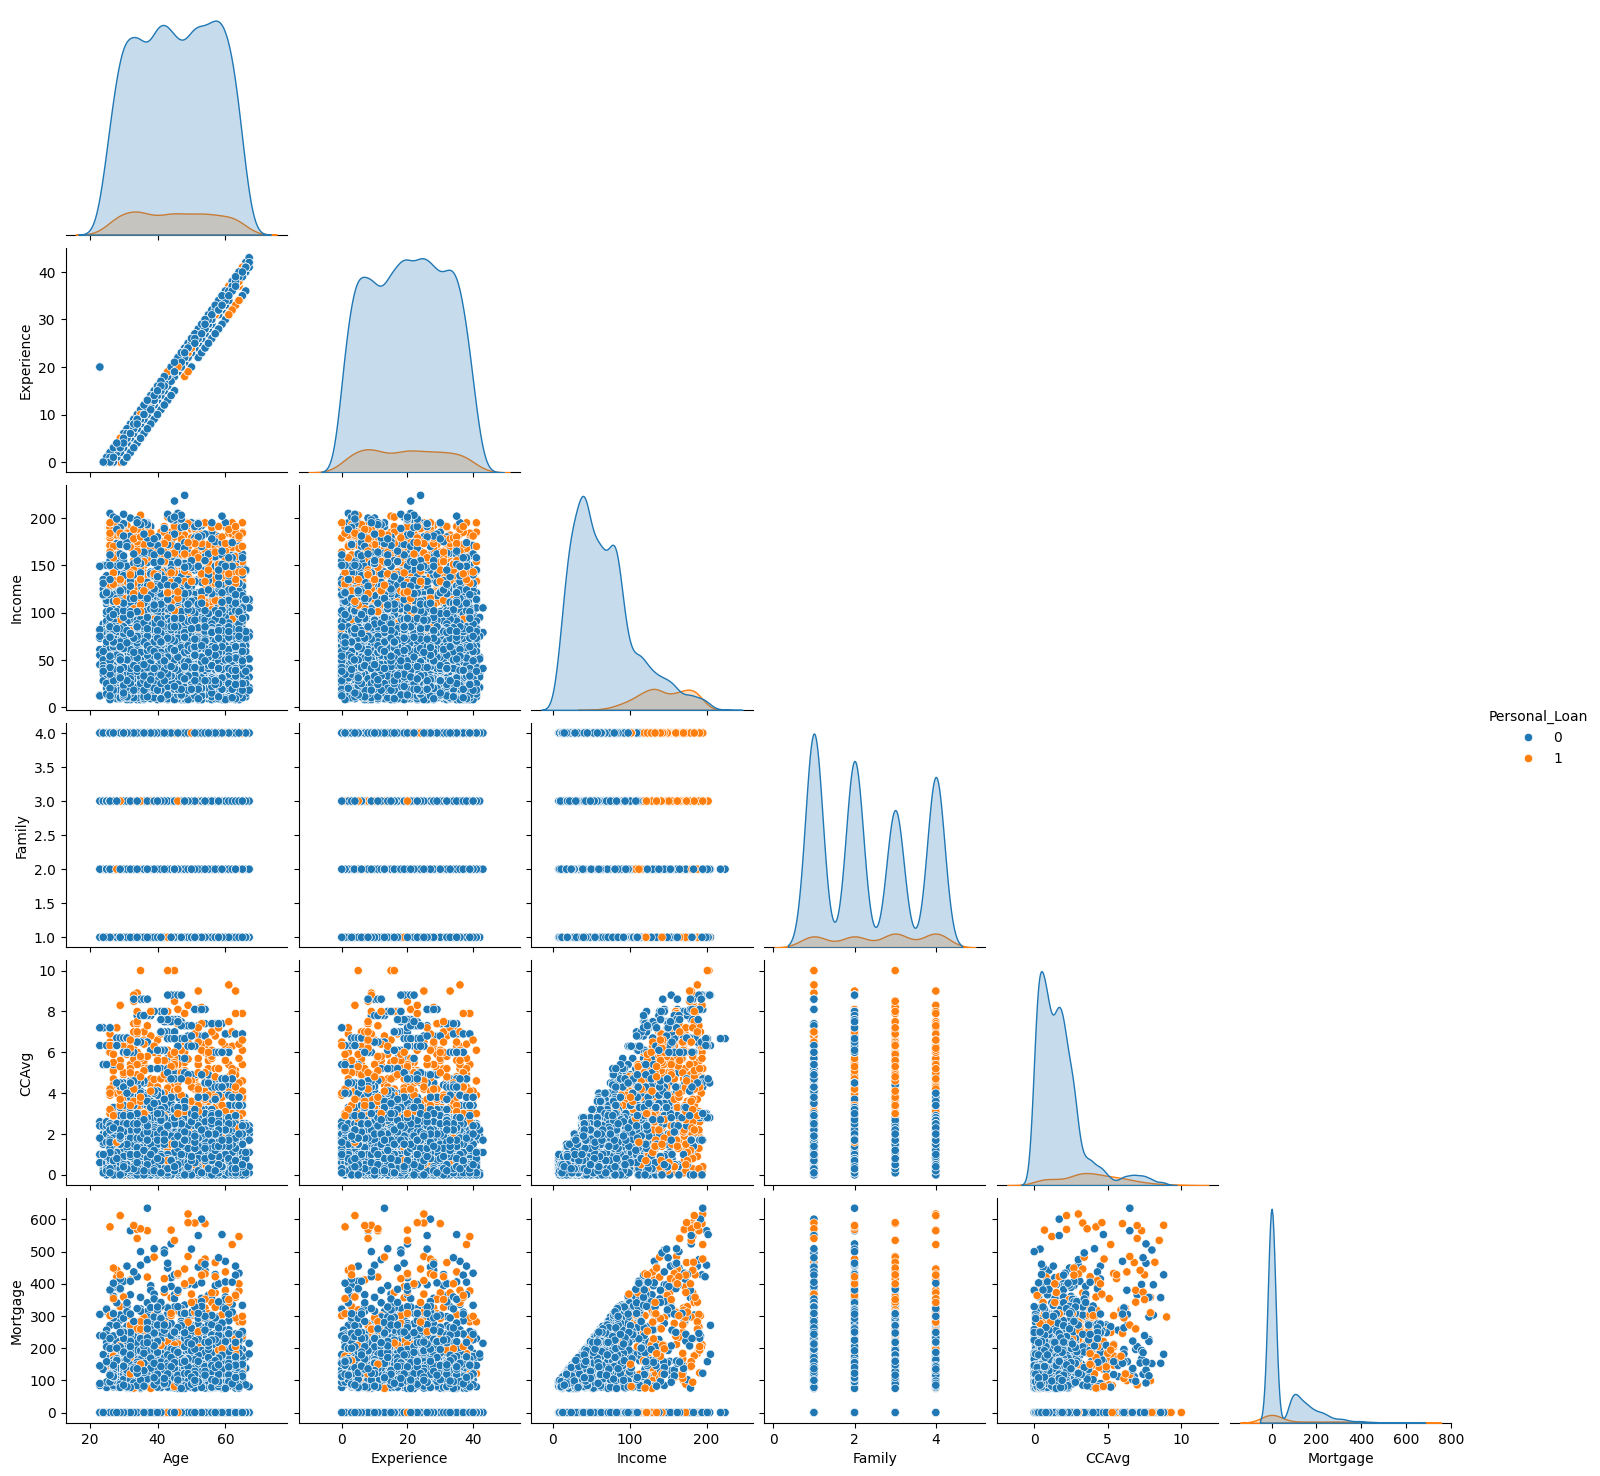

In [33]:
# figure size
plt.figure(figsize = (14, 8))
# plotting pairplot for bivariate analysis we considering thos column only whoes have continous values for this pair plot.
sns.pairplot(data = df, vars = df[['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']], hue = 'Personal_Loan', diag_kind= 'kde', corner = True)
plt.show()

- Age and Experience show a direct relationship, meaning as age increases, experience also tends to increase. However, when analyzed with respect to personal loans, there is no consistent pattern observed. In some cases, customers with lower age and experience have taken loans, while in other cases, customers with higher age and experience have not opted for loans.

- Age & Income not any correlation, but when analyzed with respect to personal loan, it indicating those who have high income they shown interest on personal loan.

- CCAvg (Average credit card spend monthly) & Age is not any correlation, some customers has low age but spending more via credit card, reversely those who are high income spending less via credit card. but when analyzed with respect to Personal Loan, it is indicating those who spending more via credit card they are shown interest in personal loan.

- Age & Family there is no any indication for personal loan interest from customer. very few like outliers (Exceptional cases)

- Income & Experience there is no any strong correlation, some customers are less experiece but earning more or high experience, low income, but when we analyzing with respect to personal loan it clearly indicating more income customers shown interest in personal loan.

- CCAvg (Average credit card spend monthly) & Experience has not that much strong correlation between them, but when we analyzing with personal loan it is indicating those who are spending more on credit card they shown interest in personal loan.

- Experience & Family there is no any indication for personal loan interest from customer. very few like outliers (Exceptional cases).

- CCAvg (Average credit card spend monthly) & Income has strong positive correlation between them & when we analyzing with respect to personal loan it is clearly indicating those who are earning more & spending more via credit card those customers are shown interest in personal loan.

- Income & Family there are not any consistency but those who are earning more & those family size is 3 to 4 those are shown interest in personal loan.

- Age & Mortgage, there is not correlation & also personal loan interset of customers are not consistent or not making any pattern. Smae with Experience & Mortgage also.

- Income & Mortgage having strong postivie correlation between them. & also indicating thos who's earning more & whoes Mortgage House value is high those customers are shown interest in personal loan.

- Family & Mortgage, those customers shown interest in personal loan whoes Mortgage House value is high.

- CCAvg (Average credit card spend monthly) & Mortgag, have high postive correlation, this cusotmers spending more via credit cards. But here some customer shown interest in personal loan whoes spending less via credit card & also whoes mortgage value is high & spending more via credit card. But some customers whoes not shown interest on personal loan whoes mortgage value is <=280 & CCAvg <= 3.5 (quite interesting pattern)

,Education,Personal_Loan,Percentage
0,1,0,0.401
1,1,1,0.019
2,2,0,0.244
3,2,1,0.036
4,3,0,0.259
5,3,1,0.041


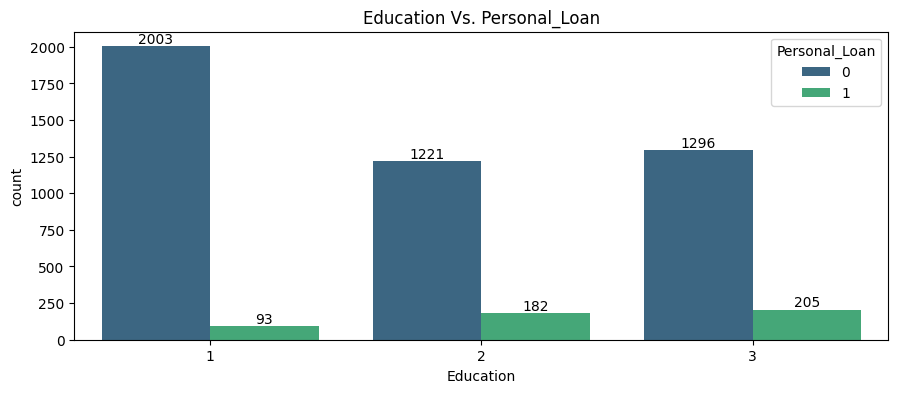

In [34]:
bargraph_plot(df, 'Education', 'Personal_Loan')

* Customers with Professional (3) and Graduate (2) education levels show a higher interest in personal loans compared to Undergraduate (1) customers. [ Only for those who shown interest in personal loan]

,Securities_Account,Personal_Loan,Percentage
0,0,0,0.812
1,0,1,0.084
2,1,0,0.092
3,1,1,0.012


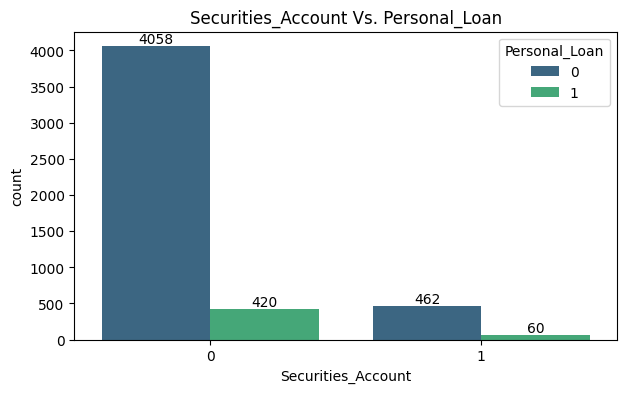

In [35]:
bargraph_plot(df, 'Securities_Account', 'Personal_Loan')

-  1% customers have there security account in bank & shown interest for personal loan.

,CD_Account,Personal_Loan,Percentage
0,0,0,0.872
1,0,1,0.068
2,1,0,0.032
3,1,1,0.028


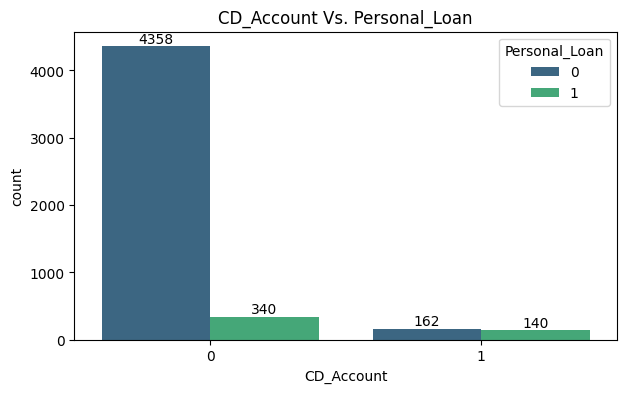

In [36]:
bargraph_plot(df, 'CD_Account', 'Personal_Loan')

Those who have there deposite Certification account in bank (302 customers) out of that 140 (46.35%) Customers shown interest for personal loan. & those not have there CD Account in bank out of that 7% customers shown interest for personal loan.

,Online,Personal_Loan,Percentage
0,0,0,0.365
1,0,1,0.038
2,1,0,0.539
3,1,1,0.058


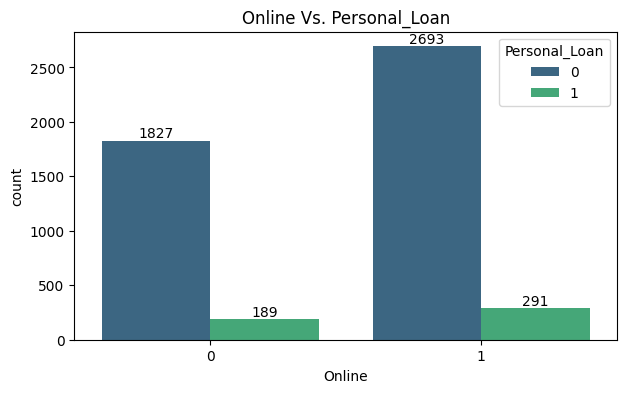

In [37]:
bargraph_plot(df, 'Online', 'Personal_Loan')

* 9.3% customers was shown interest in personal loan from those who are not using online bank service.
* 9.75% cusomters was shown interest in personal loan from those who are using online bank services.

,CreditCard,Personal_Loan,Percentage
0,0,0,0.639
1,0,1,0.067
2,1,0,0.265
3,1,1,0.029


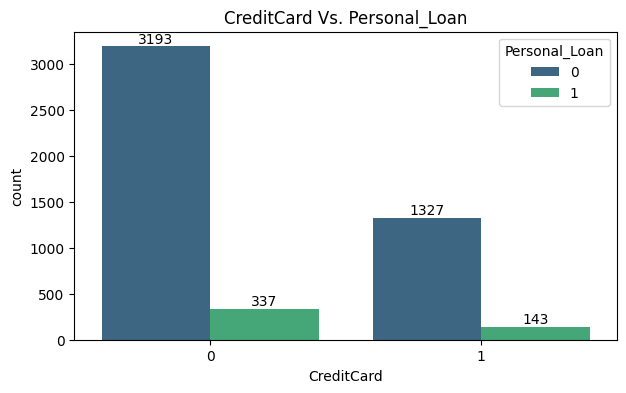

In [38]:
bargraph_plot(df, 'CreditCard', 'Personal_Loan')

* 9.54% of customers was shown intrest for personal loan from those who are not using other banks credit card. It's a good indication.
* 9.73% of customers shown in interest for personal loan from those who are using other banks credit cards.

## **Data Prepration**

**Objective 1:**

Our primary objective is to predict whether a customer is likely to purchase a personal loan.

Since the dataset contains a target variable with binary values (1 = Took Loan, 0 = Did Not Take Loan), this is a supervised classification problem, not an unsupervised one.

As the target variable is categorical (binary) rather than continuous, we will use a Logistic Regression model to estimate the probability of a customer opting for a personal loan.

In [39]:
# Zip code column we are going to remove form table, because zipcode & target column doesn't have any relationship with each other (~0.00 correlation)
df.drop('ZIPCode', axis=1, inplace = True)

In [40]:
# Defining the dependent & independent variables

X = df.drop('Personal_Loan', axis= 1)
y = df['Personal_Loan']

In [41]:
X.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard
0,25,1.000,49,4,1.600,1,0,1,0,0,0
1,45,19.000,34,3,1.500,1,0,1,0,0,0
2,39,15.000,11,1,1.000,1,0,0,0,0,0
3,35,9.000,100,1,2.700,2,0,0,0,0,0
4,35,8.000,45,4,1.000,2,0,0,0,0,1


In [42]:
# Train-Test Split
# spliting the data fr train & test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state= 42,
    stratify=y # is used during train-test split to ensure that the distribution of the target variable (y) remains the same in both training and testing datasets.
)

## **Scalling data only for logistic regression**

In [43]:
# importing StanderedScaler model for scalling data
scaler = StandardScaler()

# fit & transform (scale) training data
X_train_scaled = scaler.fit_transform(X_train)

# transform (scale) the test data
X_test_scaled = scaler.transform(X_test)


## **Model Building**

### Logistic Regression

In [44]:
# defining Logistic Regression model
lr = LogisticRegression()

# fit the data in model from training set
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [45]:
# predicting the output on train data
y_pred_lr_train = lr.predict(X_train_scaled)

# predicting the output on test data
y_pred_lr_test = lr.predict(X_test_scaled)

# printing output
print(f"Prediction on train data from model : {y_pred_lr_train}")
print(f"Prediction on test dat from model : {y_pred_lr_test}")

Prediction on train data from model : [0 0 0 ... 0 0 0]
Prediction on test dat from model : [0 0 0 ... 0 0 0]


In [46]:
# prediction probability on trained data
y_prob_lr_train = lr.predict_proba(X_train_scaled)[:,1]

# prediction probability on test data
y_prob_lr_test = lr.predict_proba(X_test_scaled)[:,1]

# printing output
print(f"Prediction Probability of trained data : {y_prob_lr_train}")
print(f"Prediction probability of test data : {y_prob_lr_test}")

Prediction Probability of trained data : [6.95067223e-03 2.98405325e-05 1.41136343e-03 ... 6.65933499e-02
 5.66923373e-02 9.44073959e-04]
Prediction probability of test data : [0.00063199 0.0015424  0.00108835 ... 0.00347993 0.00517567 0.07009574]


In [47]:
# checking the accuracy on trained data
print("Accuracy on train data :", accuracy_score(y_train, y_pred_lr_train))
print("Accuracy on test data :", accuracy_score(y_test, y_pred_lr_test))

Accuracy on train data : 0.9517142857142857
Accuracy on test data : 0.9526666666666667


* Model accuracy on train data is 95.8% which is high accuracy & 95.6% on test data, indicating model is not overfitted or underfitted.
* Model learned good amount of data pattern. Model is generalizing well.
* But, accuracy alone can't explain that much evalution or performance about the model so we need to check other matricses also.

**Evaluation on Train Data**

In [48]:
# checking confusion matrics on train data
cm_train = confusion_matrix(y_train, y_pred_lr_train)
print(f"Confusion matrics on Train Data \n{cm_train}")

Confusion matrics on Train Data 
[[3122   42]
 [ 127  209]]


In [49]:
TN = cm_train[0,0] # True Negative
FP = cm_train[0,1] # False Positive
FN = cm_train[1,0] # False Negative
TP = cm_train[1,1] # True Positive

# converting this into df
original_train_cm = pd.DataFrame({
    'Original_Metric': ['TN', 'FP', 'FN', 'TP'],
    'Original_Value': [TN, FP, FN, TP]
})


print(f"True Negative : {TN} \nFalse Positive : {FP} \nFalse Negative : {FN} \nTrue Positive : {TP}")
print()

Error_rate_train = ((( FP + FN ) / (FP + FN + TP + TN))*100).round(2)
print(f"Error rate on train : {Error_rate_train}")

True Negative : 3122 
False Positive : 42 
False Negative : 127 
True Positive : 209

Error rate on train : 4.83


The model correctly identified 3,122 True Negatives customers who did not take a loan and 209 True Positives customers who did take a loan. However, it encountered 42 False Positives, where it incorrectly predicted a loan was taken, and 127 False Negatives, where it failed to identify customers who actually took a loan.

Error rate is around 5%

In [50]:
# classification report on train data
print(classification_report(y_train, y_pred_lr_train))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3164
           1       0.83      0.62      0.71       336

    accuracy                           0.95      3500
   macro avg       0.90      0.80      0.84      3500
weighted avg       0.95      0.95      0.95      3500



Our model shows high accuracy on trained data around 95%, but the recall (62%) indicates it is missing nearly 38% of customers who actually take loans.
[ from train dataset 336 cases were there whoes takes loan but, our model recall 62% from them which is around 208 customers, remaining 128 cases also take loan in actual but our model missing those cases ]

- This is missleading, may be model/dataset is imbalanced.

**Evaluation on Test Data**

In [51]:
# Checking confusion matrics on test dataset
cm_test = confusion_matrix(y_test, y_pred_lr_test)
print(f"Confusion matrics on Test Data : \n{cm_test}")

Confusion matrics on Test Data : 
[[1336   20]
 [  51   93]]


In [52]:
TN = cm_test[0,0] # True Negative
FP = cm_test[0,1] # False Positive
FN = cm_test[1,0] # False Negative
TP = cm_test[1,1] # True Positive

# converting this into df
original_test_cm = pd.DataFrame({
    'Original_Metric': ['TN', 'FP', 'FN', 'TP'],
    'Original_Value': [TN, FP, FN, TP]
})


print(f"True Negative : {TN} \nFalse Positive : {FP} \nFalse Negative : {FN} \nTrue Positive : {TP}")
print()
# calculating error rate
Error_rate_test = (((FP + FN) / (FP + FN + TP +TN))*100).round(2)
print(f"Error Rate on Test : {Error_rate_test}")

True Negative : 1336 
False Positive : 20 
False Negative : 51 
True Positive : 93

Error Rate on Test : 4.73


In test data, 1336 is correct predicted who did not took personal loan & 93 cases were True Postive who did take a loan. However, 20 cases False positive, where it is incorrectly predicted a loan was taken, and 51 cases are False Negative, predicted incorrectly this customers were actually took loan.

In [53]:
# classification report on test data
print(classification_report(y_test, y_pred_lr_test))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1356
           1       0.82      0.65      0.72       144

    accuracy                           0.95      1500
   macro avg       0.89      0.82      0.85      1500
weighted avg       0.95      0.95      0.95      1500



In test data, High level of Model accuracy around 95%, but recall(65%) indicate it is missing nearlly around 34% cases whoes actually take loan. The model might be missleading the marketing, to approach towards the potential customers.

**Need to work on Recall, So interpreting these results to improve the model's performance.**

**Strategies to Improve Performance**

> **Adjust the Classification Threshold :**
  * By default, models use a probability threshold of 0.5 ( will try to make keep lower value)
  * lower Threshold makes model more sensitive & increase recall.

> **Feature Engineering & selection :**
  * Add new features.
  * Scalling the numerical features

> **Ensemble Algorithms :**
  * Switch model from simple model to Random Forest, XGBoost or LightGBM ( this are handles imbalanced financial data more robustly than basic Logistic Regression

#### **We decisided to go with  Adjust the Classification Threshold to handle imbalanced data**

### For Train Dataset

In [54]:
# defining a variable for prediction probability
y_prob_lr_train_new = lr.predict_proba(X_train_scaled)[:,1]

# defining a varibale to stor threshold results
train_threshold_results = []

# taking a range start from 0.1 & end on 0.6 & step size is 0.02 for each iteration
for i in np.arange(0.1, 0.6, 0.02) :

  # Applying threshold
  y_pred_train_iter = (y_prob_lr_train_new > i).astype(int)

  # evaluation matrics
  accu = accuracy_score(y_train, y_pred_train_iter)
  prec = precision_score(y_train, y_pred_train_iter)
  rec = recall_score(y_train, y_pred_train_iter)
  f1 = f1_score(y_train, y_pred_train_iter)

  # storing result
  train_threshold_results.append({
      'Threshold' : round(i, 2),
      'Accuracy' : round(accu, 2),
      'Precision' : round(prec, 2),
      'Recall' : round(rec, 2),
      'F1-Score' : round(f1, 2)
  })

# View result
df_train_threshold_results = pd.DataFrame(train_threshold_results)
print(df_train_threshold_results)

    Threshold  Accuracy  Precision  Recall  F1-Score
0       0.100     0.890      0.460   0.890     0.610
1       0.120     0.900      0.500   0.870     0.630
2       0.140     0.910      0.530   0.850     0.650
3       0.160     0.920      0.540   0.830     0.660
4       0.180     0.920      0.570   0.810     0.670
5       0.200     0.930      0.590   0.800     0.680
6       0.220     0.930      0.620   0.790     0.690
7       0.240     0.930      0.630   0.770     0.690
8       0.260     0.940      0.640   0.760     0.700
9       0.280     0.940      0.670   0.740     0.700
10      0.300     0.940      0.700   0.730     0.710
11      0.320     0.950      0.710   0.720     0.720
12      0.340     0.950      0.740   0.720     0.730
13      0.360     0.950      0.760   0.710     0.730
14      0.380     0.950      0.760   0.690     0.720
15      0.400     0.950      0.770   0.670     0.720
16      0.420     0.950      0.800   0.670     0.730
17      0.440     0.950      0.810   0.660    

In [55]:
# defining a variable for prediction probability
y_prob_lr_test_new = lr.predict_proba(X_test_scaled)[:,1]

# defining a varibale to stor threshold results
test_threshold_results = []

# taking a range start from 0.1 & end on 0.6 & step size is 0.02 for each iteration
for i in np.arange(0.1, 0.6, 0.02) :

  # Applying threshold
  y_pred_test_iter = (y_prob_lr_test_new > i).astype(int)

  # evaluation matrics
  accu = accuracy_score(y_test, y_pred_test_iter)
  prec = precision_score(y_test, y_pred_test_iter)
  rec = recall_score(y_test, y_pred_test_iter)
  f1 = f1_score(y_test, y_pred_test_iter)

  # storing result
  test_threshold_results.append({
      'Threshold' : round(i, 2),
      'Accuracy' : round(accu, 2),
      'Precision' : round(prec, 2),
      'Recall' : round(rec, 2),
      'F1-Score' : round(f1, 2)

  })

# View result
df_test_threshold_results = pd.DataFrame(test_threshold_results)
print(df_test_threshold_results)

    Threshold  Accuracy  Precision  Recall  F1-Score
0       0.100     0.900      0.480   0.890     0.620
1       0.120     0.910      0.510   0.880     0.650
2       0.140     0.920      0.550   0.870     0.670
3       0.160     0.920      0.560   0.850     0.670
4       0.180     0.930      0.580   0.850     0.690
5       0.200     0.930      0.600   0.840     0.700
6       0.220     0.940      0.630   0.830     0.720
7       0.240     0.940      0.660   0.830     0.740
8       0.260     0.940      0.680   0.780     0.730
9       0.280     0.940      0.690   0.760     0.730
10      0.300     0.940      0.690   0.750     0.720
11      0.320     0.940      0.700   0.720     0.710
12      0.340     0.940      0.710   0.720     0.710
13      0.360     0.950      0.720   0.700     0.710
14      0.380     0.950      0.760   0.690     0.720
15      0.400     0.950      0.760   0.690     0.730
16      0.420     0.950      0.780   0.690     0.730
17      0.440     0.950      0.790   0.680    

Based on "train_threshold_results" results, we have mapped out the trade offs. Now need to pick the threshold that matches our business objective.

> **For Train Data :**

**We select threshould 0.34** because at this point our **Precision is 0.740, Recall is 0.720 & F1-Score is 0.730.** Which indicating balanced dataset & result. Because it gives much **better recall 0.720 than previous 0.620 while maintaining a solid precision 0.740.**

> **For Test Data :**

**We select threshould 0.34** because at this point our **Precision is 0.710, Recall is 0.720 & F1-Score is 0.730.** Which indicating balanced dataset & result. Because it gives much **better recall 0.720 than previous 0.620 while maintaining a solid precision 0.740.**

#### **Reason:**

Previously, the model showed a precision of 0.83 and a recall of 0.62 (F1-score: 0.71) on the training data & precision of 0.82 and a recall of 0.65 (F1-score: 0.72) on the test data . The relatively low recall indicates that the model was missing a significant number of customers who have a high likelihood of taking a personal loan.

Therefore, the objective is to improve recall in order to capture a larger portion of potential customers who are likely to purchase a personal loan.

Our objective is to more personal loan customers **(recall is important)**

### **New Confusion Matrix (Threshold = 0.34) for train & test data**

In [56]:
# for train data

# defing the threshould value
final_threshould = 0.340

# passing the data to find probability of prediction
y_prob_lr_train_final = lr.predict_proba(X_train_scaled)[:,1]

# passing the threshould value to find the probability of prediction
y_final_train = (y_prob_lr_train_final >= final_threshould ).astype(int)


# plotting the confusion matrics
Updated_CM_train = confusion_matrix( y_train, y_final_train)
print(f"Confusion matrics for Train data : \n\n{Updated_CM_train}")

# finding the TN,FP,FN,TP and strong into a df
T_TN = Updated_CM_train[0,0]
T_FP = Updated_CM_train[0,1]
T_FN = Updated_CM_train[1,0]
T_TP = Updated_CM_train[1,1]

print() # for space genration
# printing value for confusion matrics
print(f"True Negative : {TN} \nFalse Positive {FP} \nFalse Negative : {FN} \nTrue Positive : {TP}")

print() # for space genration
# calculating error rate
error_rate_on_train = (((T_FP + T_FN) / (T_FP + T_FN + T_TP + T_TN) )*100).round(2)
print(f"Error Rate on train : {error_rate_on_train}")

# keeping confusion matrics values into dataframe
updated_train_cm = pd.DataFrame({
    'Updated_Metric': ['TN', 'FP', 'FN', 'TP'],
    'Updated_Value': [T_TN, T_FP, T_FN, T_TP]
})

Confusion matrics for Train data : 

[[3077   87]
 [  94  242]]

True Negative : 1336 
False Positive 20 
False Negative : 51 
True Positive : 93

Error Rate on train : 5.17


When we lower the threshould is 0.50 to 0.34 in train dataset, our True positive has increased from 209 to 242 (+33) customers. So revenue will automatically increase.
But also Our False positive increased from 42 to 87 (+45) means our campaign will target unneceasry 45 customers.(will increase marketing budget) but there is chance to revenue, if they show interest for personal loan then it will help to revenue additiono.

In [57]:
# for test data

# defining the threshould value
final_threshould = 0.340

# passing the data to find probability of prediction
y_prob_lr_test_final = lr.predict_proba(X_test_scaled)[:,1]

# passing the threshould value to find the probability of prediction
y_final_test = (y_prob_lr_test_final >= final_threshould).astype(int)

# plotting the confusion matrics
Updated_CM_test = confusion_matrix( y_test, y_final_test)
print(f"Confusion Matrics for Test data : \n\n{Updated_CM_test}")


# finding the TN,FP,FN,TP and strong into a df
test_TN = Updated_CM_test[0,0]
test_FP = Updated_CM_test[0,1]
test_FN = Updated_CM_test[1,0]
test_TP = Updated_CM_test[1,1]

print() # for space addition only

print(f"True Negative : {test_TN} \nFalse Positive : {test_FP} \nFalse Negative : {test_FN} \nTrue Positive : {test_TP}")

print() # for sapce adding
# calculating error rate
error_rate_on_test = (((test_FP + test_FN ) / (test_TN + test_FP + test_FN + test_TP ))*100).round(2)

print(f"Error Rate on test data : {error_rate_on_test}")
print()


updated_test_cm = pd.DataFrame({
    'Updated_Metric': ['TN', 'FP', 'FN', 'TP'],
    'Updated_Value': [test_TN, test_FP, test_FN, test_TP]
})

Confusion Matrics for Test data : 

[[1313   43]
 [  41  103]]

True Negative : 1313 
False Positive : 43 
False Negative : 41 
True Positive : 103

Error Rate on test data : 5.6



When we are lower the threshould value on test data prediction form 0.50 to 0.34, Our True Positive has increase from 93 to 105 (12), indicating model adding more chances to covering more potiential customers. But same time our False positive has increased from 20 to 43 (+23), model adding more customers whoes actually won't loan but model telling approach them also. here plus point is that marketing campaign not lossing any chance to revenue addition.

In [58]:
# Train summary :

train_cm_summary = pd.concat([original_train_cm, updated_train_cm], axis = 1, join = 'inner')
train_cm_summary = train_cm_summary[['Original_Metric','Original_Value', 'Updated_Value' ]]
train_cm_summary['Change'] = train_cm_summary['Updated_Value'] - train_cm_summary['Original_Value']


# test Summary :

test_cm_summary = pd.concat([original_test_cm, updated_test_cm], axis = 1, join = 'inner')
test_cm_summary = test_cm_summary[['Original_Metric','Original_Value', 'Updated_Value' ]]
test_cm_summary['Change'] = test_cm_summary['Updated_Value'] - test_cm_summary['Original_Value']


display("Confusion matrics summary on Train")
print()
print(train_cm_summary)
print()
print()
display("Confusion matrics summary on Test")
print()
print(test_cm_summary)
print()

'Confusion matrics summary on Train'


  Original_Metric  Original_Value  Updated_Value  Change
0              TN            3122           3077     -45
1              FP              42             87      45
2              FN             127             94     -33
3              TP             209            242      33




'Confusion matrics summary on Test'


  Original_Metric  Original_Value  Updated_Value  Change
0              TN            1336           1313     -23
1              FP              20             43      23
2              FN              51             41     -10
3              TP              93            103      10



After threshould = 0.34 on **Train Data**,

Model capture 33 more customers (TP) & reduced missed customers (FN) from 127 to 94. But False Positive(FP) increased by 45, which indicating model trying to reach on more customers might be they dont want personal loan. but there will chance to convert. good point is revenue not gona miss(Higher revenue opportunity).




After Threshould = 0.34 on **Test Data**,

Model capture 10 more customers (TP) & reduced missed customers (FN) from 52 to 41. But False positive (FP) cases increased by 23, which is indicating model will trying to reach on more customers. But revenue not goan miss. (Higher revenue opportunity).




**Thsi is Good ->**
* Missing a buyer = lost revenue
* Targeting a non-buyer = small marketing cost

In [59]:
# definign a function to detect should target the customer or not
def target_cusotmer_or_not(X):
    # scalling the X data from normalise the values by StanderedScaler() function
    X_scaled = scaler.transform(X)

    # finading the probability of prediction from X scaled data
    probs = lr.predict_proba(X_scaled)[:, 1]

    # returning the output
    return ["Target for Loan" if p >= 0.34 else "Do Not Target" for p in probs]


In [60]:
import numpy as np

# Input function iteraters
attributes = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']

#Start with an empty list
user_input_data = []

# Collect inputs from user
print("Please enter customer details:")

for i in attributes:
    # input iterater
    a = float(input(f"{i} : "))

    # appendinginputed value in to user_input_list
    user_input_data.append(a)

# Convert to 2D list of "user_input_data" for the model

new_customers = np.array([user_input_data])

# Get prediction from users inputed data
predictions = target_cusotmer_or_not(new_customers)
print(f"\nResult: {predictions[0]}")


Please enter customer details:


KeyboardInterrupt: Interrupted by user

In [61]:
# reference for input in above
df[df['Personal_Loan']==1].head(1)

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
9,34,9.000,180,1,8.900,3,0,1,0,0,0,0


## **Driving attributes**

In [62]:
# creating a df, to find coefficient for attributes to identify influencing attributes
# creatng df
driving_attributes = pd.DataFrame({
    'Feature' : X.columns,   # columns
    'Coefficient' : lr.coef_[0]   # coefficient
}).sort_values(by = 'Coefficient', ascending=False)  # sorting the df

print(driving_attributes)

               Feature  Coefficient
2               Income        2.375
5            Education        1.365
8           CD_Account        0.931
3               Family        0.783
4                CCAvg        0.236
6             Mortgage        0.069
0                  Age        0.011
1           Experience        0.010
7   Securities_Account       -0.321
9               Online       -0.328
10          CreditCard       -0.497


Securities Account & Online & creditCard attributes has negative coefficient. They are not contributing

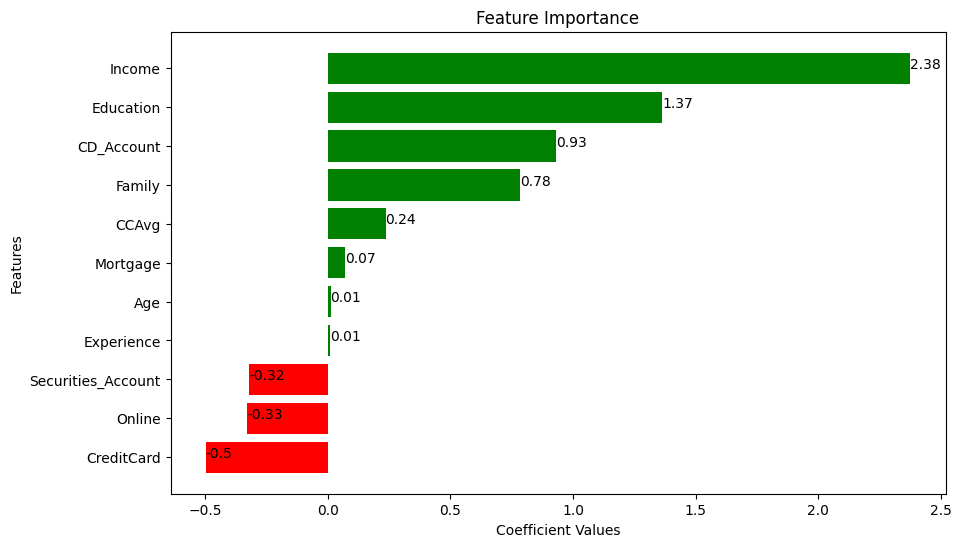

In [78]:
driving_attributes = driving_attributes.sort_values(by = 'Coefficient')

# Visualization
plt.figure(figsize=(10,6))

#assigning colors
colors = ['green' if x > 0 else 'red' for x in driving_attributes['Coefficient']]

plt.barh(driving_attributes['Feature'], driving_attributes['Coefficient'], color=colors)
# Label & title
plt.xlabel("Coefficient Values")
plt.ylabel("Features")
plt.title("Feature Importance")

# plotting the values in barh
for index, value in enumerate(driving_attributes['Coefficient']):
    plt.text(value, index, round(value, 2))

plt.show()


* The bar chart clearly shows that Income, Education, and CD Account are the most influential factors positively impacting loan purchase, while features like Credit Card and Online usage negatively influence the likelihood.

In [63]:
# summary, How feature values differ between 0 vs 1
df.groupby('Personal_Loan')[driving_attributes['Feature']].mean().T

Personal_Loan,0,1
Income,66.237,144.746
Education,1.844,2.233
CD_Account,0.036,0.292
Family,2.373,2.612
CCAvg,1.729,3.905
Mortgage,51.789,100.846
Age,45.367,45.067
Experience,20.207,19.844
Securities_Account,0.102,0.125
Online,0.596,0.606


In [64]:
# scaling the df
X_scaled = scaler.fit_transform(X)
# adding a loan probability column in df
df['loan_probability'] = lr.predict_proba(X_scaled)[:,1]

In [65]:
# to find customer segmentation
# we decisided to bifurcate the segmentation into 3 category
# High Value, Medium Value, Low Value

prob_thresholds = np.arange(0.1, 0.9, 0.01)
# predicting probability on X test dataset
loan_probability = lr.predict_proba(X_test_scaled)[:,1] # test data
result = []

for t in prob_thresholds :
  y_pred = (loan_probability > t).astype(int)
  # precision score
  prec = precision_score(y_test, y_pred)
  # recall score
  rec = recall_score(y_test, y_pred)
  # F1 Score
  f1 = f1_score(y_test, y_pred)

  result.append([t, prec, rec, f1])

df_tresh = pd.DataFrame(result, columns = ['Threshold','Precision','Recall','F1'])

In [66]:
df_tresh.head()

,Threshold,Precision,Recall,F1
0,0.100,0.478,0.889,0.621
1,0.110,0.496,0.882,0.635
2,0.120,0.512,0.882,0.648
3,0.130,0.527,0.875,0.658
4,0.140,0.548,0.868,0.672


In [67]:
# now we bifurcating the segmentation
high_thresh = df_tresh[df_tresh['Precision'] >= 0.8 ].iloc[0]['Threshold']
mid_thresh = df_tresh[df_tresh['Recall'] >= 0.7].iloc[0]['Threshold']

In [71]:
# function to identify customer category segmentation
def segment(x):
  if x >= high_thresh :
    return 'High Value'
  elif x >= mid_thresh :
    return 'Medium Value'
  else :
    return 'Low Value'

# applying this segment function in df
df['Segment'] = df['loan_probability'].apply(segment)
df['loan_probability'] = (df['loan_probability'] * 100 ).round(2)

In [72]:
# Segmentation
summary = df.groupby('Segment').mean().reset_index()
display(summary)

,Segment,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,loan_probability
0,High Value,44.523,19.343,159.324,2.598,4.371,2.254,110.608,0.802,0.133,0.362,0.636,0.312,78.738
1,Low Value,45.520,20.374,59.967,2.344,1.551,1.818,47.674,0.013,0.104,0.025,0.603,0.302,1.355
2,Medium Value,44.537,19.226,116.574,2.651,3.111,2.086,84.288,0.209,0.088,0.106,0.520,0.219,22.104


## **Segmentation Observation & Conclusion :**

###> **High-Value Segment (Primary Target):**
* **The Key Drivers :** This group has a massive average Income of 159.32 and the highest Education (2.25).
* **Loan Probability :** They have a 78.7% perdicted probability of a taking loan.
* **Product Synergy:** They have the highest concentration of CD Accounts (36.2%), confirming that existing asset customers are best loan leads.
* This is where nearly all **True Positives** are located.

###> **Medium-Value Segment (Opportunity area) :**
* Moderate Income (116.57) and moderate CCAvg (3.11).
* **Loan Probability:** A 22.1% probability
* While not guaranteed buyers, this segment is best candidate for the **0.34 Threshold.** by targeting this group, we can capture the "On-The-fence" customers who might buy if given a slightly better interest rate.

###> **Low-Value Segment :**
* Low Income (59.9) and very low CCAvg (1.55).
* **Loan Probability:** Only 1.4%
* Despite being similar in Age and Experience to the other groups, their financial profile makes them highly unlikely to take a loan.


## **Conclusion :**

* We achieved a 94% Accuracy and 72% Recall by optimizing our classification threshold to 0.34 from 0.50. This allows the bank to capture the majority of the market while maintaining high efficiency.

* Income, Education, CD_Account, Family, CC-Avg are the primary determinants of loan uptake. Factors like Age and Experience have negligible impact.

* **Target Strategy :** Marketing team from bank, they should to adopt two-tier marketing strategy.

  * High Value (Tire-1) : Aggressive, direct targeting. This group has a 78%+ conversion potential.
  * Medium Value (Tier-2) : elective targeting using personalized offers. This group represents the "marginal" buyers that our optimized model is now designed to catch.

* **Efficiency :** By ignoring the Low-Value segment, the bank can reduce marketing waste by approximately 60-70% while losing less than 2% of potential loan revenue.
